In [5]:
import numpy as np
N=100
a=0.5
if N%2 == 1:
    N_0=N-1
if N%2 == 0:
    N_0=N   
n=np.zeros((int(N_0/2+1)))
for i in np.arange(int(N_0/2+1)):
    n[i]=i
#print(n)
cos_2Ka=np.cos(2*np.pi*n/N)
print(cos_2Ka)

[ 1.00000000e+00  9.98026728e-01  9.92114701e-01  9.82287251e-01
  9.68583161e-01  9.51056516e-01  9.29776486e-01  9.04827052e-01
  8.76306680e-01  8.44327926e-01  8.09016994e-01  7.70513243e-01
  7.28968627e-01  6.84547106e-01  6.37423990e-01  5.87785252e-01
  5.35826795e-01  4.81753674e-01  4.25779292e-01  3.68124553e-01
  3.09016994e-01  2.48689887e-01  1.87381315e-01  1.25333234e-01
  6.27905195e-02  6.12323400e-17 -6.27905195e-02 -1.25333234e-01
 -1.87381315e-01 -2.48689887e-01 -3.09016994e-01 -3.68124553e-01
 -4.25779292e-01 -4.81753674e-01 -5.35826795e-01 -5.87785252e-01
 -6.37423990e-01 -6.84547106e-01 -7.28968627e-01 -7.70513243e-01
 -8.09016994e-01 -8.44327926e-01 -8.76306680e-01 -9.04827052e-01
 -9.29776486e-01 -9.51056516e-01 -9.68583161e-01 -9.82287251e-01
 -9.92114701e-01 -9.98026728e-01 -1.00000000e+00]


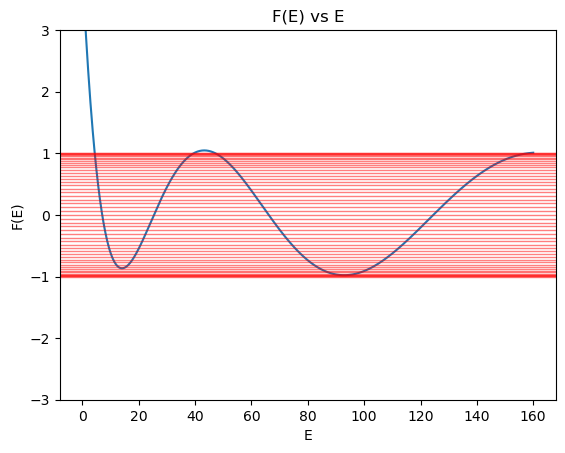

In [6]:
y1 = 2
y2 = 2
E = np.linspace(0.001, 160, 1000) 
F_values = np.cos(2 * a * np.sqrt(E)) + y1 * np.sin(2 * a * np.sqrt(E)) / np.sqrt(E) - (y1**2 + y2**2) * (np.cos(2 * a * np.sqrt(E)) - 1) / (4 * E)

import matplotlib.pyplot as plt
plt.plot(E, F_values)
plt.ylim(-3,3)
plt.xlabel('E')
plt.ylabel('F(E)')
plt.title('F(E) vs E')
#plt.grid(True)
for y in cos_2Ka:
    plt.axhline(y, color='r', linestyle='-', linewidth=1, alpha=0.5)  
#for x in [10,20]:
#    plt.axvline(x, color='g', linestyle='-', linewidth=1, alpha=0.5)  

plt.show()

In [7]:
import numpy as np

h1 = 1
m = 0.5

def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [3]:
import numpy as np    
from sympy import symbols, nsolve, cos, sin, sqrt, pi
import matplotlib.pyplot as plt
import os

def calculate_energy_levels(N, y1, y2, a, E_min, E_max, tol=1e-6):
    """
    计算给定参数下的能量级别(E值)
    参数:
        N: 系统参数
        y1, y2: 势能参数
        a: 系统参数
        E_min, E_max: 能量范围
        tol: 容差
    返回:
        排序后的唯一E值列表
    """
    N_0 = N if N % 2 == 0 else N - 1
    n_values = np.arange(int(N_0/2 + 1))
    E_sym = symbols('E')
    all_solutions = []

    for n in n_values:
        equation = cos(2 * a * sqrt(E_sym)) + y1 * sin(2 * a * sqrt(E_sym)) / sqrt(E_sym) \
                   - (y1**2 + y2**2) * (cos(2 * a * sqrt(E_sym)) - 1) / (4 * E_sym) \
                   - cos(2 * pi * n / N)
        
        solutions = []
        for E_guess in np.linspace(E_min + 0.1, E_max, 100):
            try:
                sol = nsolve(equation, E_guess, tol=1e-6)
                if E_min <= sol <= E_max:
                    is_new = True
                    for existing in solutions:
                        if abs(existing - sol) < tol:
                            is_new = False
                            break
                    if is_new:
                        solutions.append(float(sol))
            except:
                continue
        
        solutions.sort()
        all_solutions.extend(solutions)
    return sorted(list(set(round(sol/tol)*tol for sol in all_solutions)))

In [4]:
N=100
y1=2
y2=2
a=0.5
E_min=0
E_max=400
len(calculate_energy_levels(N, y1, y2, a, E_min, E_max, tol=1e-6))

329